## 1. Import libraries and load data

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

In [155]:
df = pd.read_csv(r'cleaned_data.csv')
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389168 entries, 0 to 389167
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   389168 non-null  object 
 1   stock_code    389168 non-null  object 
 2   description   389168 non-null  object 
 3   quantity      389168 non-null  int64  
 4   invoice_date  389168 non-null  object 
 5   unit_price    389168 non-null  float64
 6   cust_id       389168 non-null  float64
 7   country       389168 non-null  object 
 8   month         389168 non-null  int64  
 9   day           389168 non-null  int64  
 10  hour          389168 non-null  int64  
 11  week_days     389168 non-null  object 
 12  year_month    389168 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 38.6+ MB


## 2. Feature Engineering

In [157]:
# convert
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# split time-based
cutoff_date = df['invoice_date'].quantile(0.8)
df_train = df[df['invoice_date'] <= cutoff_date].copy()
df_test = df[df['invoice_date'] > cutoff_date].copy()


In [158]:
# tạo Amount
df_train['Amount'] = df_train['quantity'] * df_train['unit_price']

# groupby
customer_train = df_train.groupby('cust_id').agg(
    last_purchase=('invoice_date', 'max'),
    frequency=('invoice_num', 'nunique'),
    monetary=('Amount', 'sum')
).reset_index()

# Recency
current_date = df_train['invoice_date'].max()
customer_train['recency'] = (current_date - customer_train['last_purchase']).dt.days

# Avg Order Value
customer_train['avg_order_value'] = customer_train['monetary'] / customer_train['frequency']

# Purchase Interval
customer_train['purchase_interval'] = customer_train['recency'] / customer_train['frequency']
customer_train.head()

,cust_id,last_purchase,frequency,monetary,recency,avg_order_value,purchase_interval
0,12346.0,2011-01-18 10:17:00,2,154367.20,279,77183.600,139.50
1,12347.0,2011-08-02 08:48:00,5,2790.86,84,558.172,16.80
2,12348.0,2011-09-25 13:13:00,4,1797.24,29,449.310,7.25
3,12350.0,2011-02-02 16:01:00,1,334.40,264,334.400,264.00
4,12352.0,2011-09-28 14:58:00,10,3154.94,26,315.494,2.60


## 3. Label churn

In [159]:
test_customers = df_test['cust_id'].unique()

customer_train['churn'] = (~customer_train['cust_id'].isin(test_customers)).astype(int)

## 4. Data Preparation

In [160]:
features = ['recency', 'frequency', 'monetary', 'avg_order_value']

X = customer_train[features]
y = customer_train['churn']

In [161]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [162]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [163]:
print(f"📊 PHÂN CHIA DỮ LIỆU:")
print(f"   Train: {len(X_train):,} khách hàng")
print(f"   Test:  {len(X_test):,} khách hàng")
print(f"\n   Tỷ lệ churn (Train): {y_train.mean()*100:.1f}%")
print(f"   Tỷ lệ churn (Test):  {y_test.mean()*100:.1f}%")

📊 PHÂN CHIA DỮ LIỆU:
   Train: 3,148 khách hàng
   Test:  787 khách hàng

   Tỷ lệ churn (Train): 61.9%
   Tỷ lệ churn (Test):  60.1%


## 5. Machine Learning 
1. **Logistic Regression** 
2. **Random Forest**
3. **XGBoost**
4. **LightGBM**


In [164]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [165]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [166]:
xgb_model = XGBClassifier(
    random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [167]:
lgbm_model = LGBMClassifier(
    random_state=42)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 1948, number of negative: 1200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 776
[LightGBM] [Info] Number of data points in the train set: 3148, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.618806 -> initscore=0.484482
[LightGBM] [Info] Start training from score 0.484482


## 5. Model Evaluation and Comparison

In [172]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_lgbm)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_lgbm)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_lgbm)],
    'F1-Score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_lgbm)],
    'AUC-ROC': [roc_auc_score(y_test, y_prob_log), roc_auc_score(y_test, y_prob_rf), roc_auc_score(y_test, y_prob_xgb), roc_auc_score(y_test, y_prob_lgbm)]
})
results.sort_values(by='AUC-ROC', ascending=False, inplace=True)
print("\n=== Model Performance Comparison ===")
print(results)


=== Model Performance Comparison ===
                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.728081   0.703937  0.945032  0.806859  0.765913
3             LightGBM  0.701398   0.714029  0.839323  0.771623  0.729889
2              XGBoost  0.683609   0.710526  0.799154  0.752239  0.727428
1        Random Forest  0.684879   0.711069  0.801268  0.753479  0.720082


In [173]:
model_preds = {
    'Logistic Regression': y_pred_log,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm
}

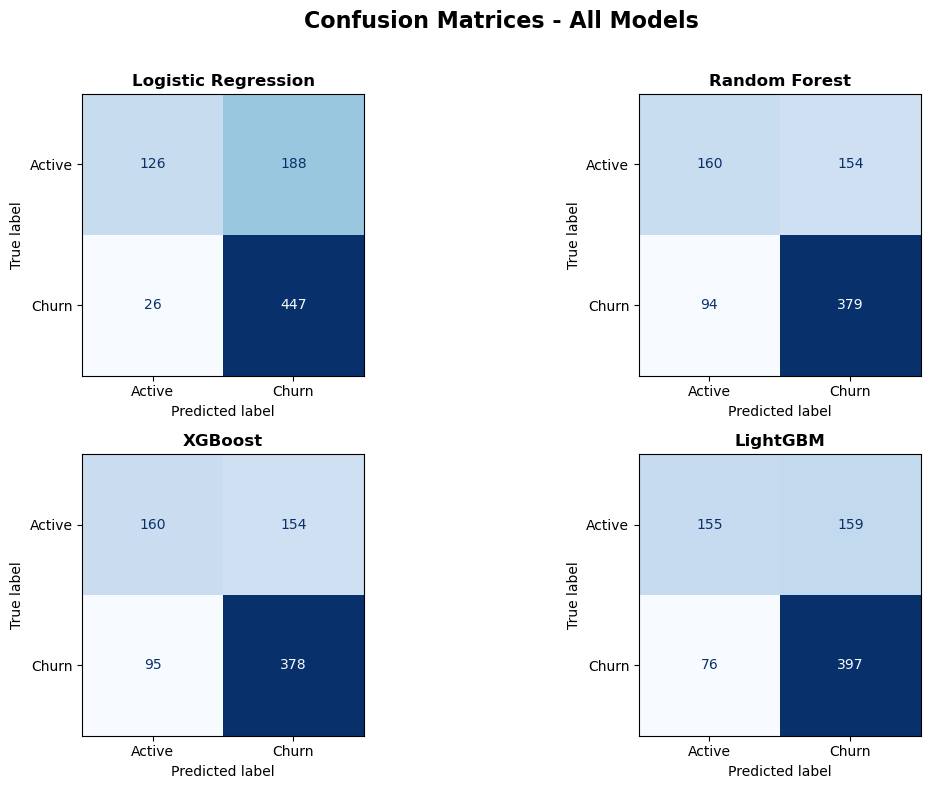

In [174]:
plt.figure(figsize=(12,8))

for i, (name, y_pred) in enumerate(model_preds.items()):
    
    ax = plt.subplot(2,2,i+1)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Active','Churn'],
        cmap='Blues',
        ax=ax,
        colorbar=False
    )

    plt.title(name, fontsize=12, weight='bold')

plt.suptitle("Confusion Matrices - All Models\n",
             fontsize=16,
             weight='bold')

plt.tight_layout()
plt.show()

### Business insights and recommendations

Logistic Regression: Recall churn rất cao bắt được gần hết khách hàng sắp rời đi nhưng hơi overpredictive dẫn đến false alarm nhiều. Hơi quá nhạy dẫn đến chi phí chăm sóc khách hàng tăng cao.

Random Forest, XGBoost: thì cân hơn logistic regression nhưng bị miss churn nhiều hơn, có thể bỏ sót khách hàng sắp rời đi. Tiết kiệm chi phí marketing nhưng nguy cơ mất khách là rất cao.

LightGBM: false alarm không quá cao nhưng vẫn bắt được nhiều khách sắp rời đi, có thể là lựa chọn tốt nhất để cân bằng giữa chi phí chăm sóc khách hàng và nguy cơ mất khách.

Tóm Tắt Feature Importance

| Đặc trưng | Ý nghĩa | Tác động |
|---|---|---|
| **Recency** | Số ngày từ lần mua cuối | Càng lâu không mua → càng dễ rời bỏ |
| **Frequency** | Số đơn hàng | Càng ít mua → càng dễ rời bỏ |
| **Monetary** | Tổng chi tiêu | Chi tiêu thấp → nguy cơ rời bỏ cao |
| **Avg Order Value** | Giá trị trung bình đơn hàng | Giá trị thấp → ít gắn bó |
| **Purchase Interval** | Khoảng cách giữa các lần mua | Khoảng cách lớn → nguy cơ rời bỏ |

---

### 📌 Kế Hoạch Hành Động

1. **Ngắn hạn**: Triển khai mô hình, xác định top 20% KH có nguy cơ rời bỏ cao nhất
2. **Trung hạn**: Xây dựng chương trình loyalty/khuyến mãi tự động dựa trên điểm churn
3. **Dài hạn**: Tích hợp thêm dữ liệu (hành vi web, phản hồi KH) để cải thiện mô hình